DATA CLEANING & PROCESSING

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("../data/raw/telecom_churn.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [5]:
# Number of rows and columns
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 243553
Number of columns: 14


In [6]:
df_original = df.copy()

print("Backup created successfully!")

Backup created successfully!


In [7]:
# Display the names of all columns
print("Column names in the dataset:\n")
for number, column in enumerate(df.columns, start=1):
    print(number, "-", column)

Column names in the dataset:

1 - customer_id
2 - telecom_partner
3 - gender
4 - age
5 - state
6 - city
7 - pincode
8 - date_of_registration
9 - num_dependents
10 - estimated_salary
11 - calls_made
12 - sms_sent
13 - data_used
14 - churn


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [9]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [10]:
#missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64


In [11]:
# duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
#unique values in every column
unique_values = df.nunique().sort_values(ascending=False)
unique_values

customer_id             243553
pincode                 213442
estimated_salary        110032
data_used                11837
date_of_registration      1220
calls_made                 119
sms_sent                    59
age                         57
state                       28
city                         6
num_dependents               5
telecom_partner              4
gender                       2
churn                        2
dtype: int64

In [13]:
# Display five random records
df.sample(5, random_state=42)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
230796,230797,Airtel,M,20,Tamil Nadu,Delhi,285677,2023-03-01,2,104752,38,47,1687,0
191985,191986,Vodafone,F,68,Uttarakhand,Delhi,679704,2022-08-18,2,71706,43,33,991,0
18778,18779,Vodafone,M,30,Goa,Mumbai,837926,2020-04-03,4,137473,-2,12,6803,0
241016,241017,Vodafone,M,22,Madhya Pradesh,Chennai,679346,2023-04-21,0,58245,32,11,2832,0
136494,136495,Reliance Jio,M,63,Tripura,Bangalore,839738,2021-11-14,4,73740,68,11,5375,0


In [14]:
# Search for columns related to churn

possible_churn_columns = [
    column for column in df.columns
    if "churn" in column.lower()
]

print("Possible churn-related columns:")

if possible_churn_columns:
    for column in possible_churn_columns:
        print("-", column)
else:
    print("No column containing the word 'churn' was found.")

Possible churn-related columns:
- churn


In [15]:
#Convert customer ID to string
df["customer_id"] = df["customer_id"].astype(str)
print(df["customer_id"].dtype)

object


In [16]:
#Convert pincode to string
df["pincode"] = df["pincode"].astype(str)
print(df["pincode"].dtype)

object


In [17]:
#Convert registration date
df["date_of_registration"] = pd.to_datetime(
    df["date_of_registration"],
    errors="coerce"
)

print(df["date_of_registration"].dtype)

datetime64[ns]


In [18]:
#Check the churn values
#1 = churned
#0 = active
print(df["churn"].value_counts(dropna=False))

churn
0    194726
1     48827
Name: count, dtype: int64


In [19]:
churn_percentage = (
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

churn
0    79.95
1    20.05
Name: proportion, dtype: float64


In [20]:
numeric_columns = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,243553.0,46.077609,16.444029,18.0,32.0,46.0,60.0,74.0
num_dependents,243553.0,1.997500,1.414941,0.0,1.0,2.0,3.0,4.0
estimated_salary,243553.0,85021.137839,37508.963233,20000.0,52585.0,84990.0,117488.0,149999.0
calls_made,243553.0,49.010548,29.453556,-10.0,24.0,49.0,74.0,108.0
sms_sent,243553.0,23.945404,14.733575,-5.0,11.0,24.0,36.0,53.0
data_used,243553.0,4993.186025,2942.019547,-987.0,2490.0,4987.0,7493.0,10991.0


In [21]:
#invalid or unusual ages
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

Minimum age: 18
Maximum age: 74


In [22]:
#negative values
non_negative_columns = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

for column in non_negative_columns:
    negative_count = (df[column] < 0).sum()
    print(column, "→ Negative values:", negative_count)

age → Negative values: 0
num_dependents → Negative values: 0
estimated_salary → Negative values: 0
calls_made → Negative values: 6713
sms_sent → Negative values: 7375
data_used → Negative values: 6050


In [23]:
usage_columns = [
    "calls_made",
    "sms_sent",
    "data_used"
]

negative_records = df[
    (df["calls_made"] < 0) |
    (df["sms_sent"] < 0) |
    (df["data_used"] < 0)
]

print("Total records containing negative usage values:",
      len(negative_records))

negative_records.head(10)

Total records containing negative usage values: 19587


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
19,20,Vodafone,M,26,Uttar Pradesh,Hyderabad,516585,2020-01-01,1,109753,95,-1,9993,0
33,34,BSNL,F,31,Haryana,Bangalore,830078,2020-01-01,2,106097,89,-2,3927,0
38,39,Reliance Jio,M,69,Gujarat,Chennai,712223,2020-01-01,1,87166,92,15,-790,0
68,69,Airtel,M,39,Kerala,Mumbai,413226,2020-01-01,2,121809,-1,13,8728,0
69,70,Reliance Jio,M,28,Kerala,Chennai,520338,2020-01-01,2,34463,36,6,-492,0
72,73,BSNL,F,43,Uttarakhand,Delhi,554046,2020-01-01,4,101224,33,44,-73,0
83,84,Reliance Jio,F,22,Assam,Hyderabad,848983,2020-01-01,2,47235,102,-1,7785,0
87,88,Airtel,F,33,Himachal Pradesh,Kolkata,100889,2020-01-01,0,122987,78,4,-149,1
90,91,BSNL,M,28,Bihar,Bangalore,638325,2020-01-01,0,31297,36,-3,2695,0


In [24]:
for column in usage_columns:
    print("\nColumn:", column)
    print("Minimum value:", df[column].min())
    print("Negative values:", (df[column] < 0).sum())


Column: calls_made
Minimum value: -10
Negative values: 6713

Column: sms_sent
Minimum value: -5
Negative values: 7375

Column: data_used
Minimum value: -987
Negative values: 6050


In [25]:
negative_records[
    [
        "telecom_partner",
        "state",
        "city",
        "calls_made",
        "sms_sent",
        "data_used",
        "churn"
    ]
].head(20)

,telecom_partner,state,city,calls_made,sms_sent,data_used,churn
0,Reliance Jio,Karnataka,Kolkata,44,45,-361,0
19,Vodafone,Uttar Pradesh,Hyderabad,95,-1,9993,0
33,BSNL,Haryana,Bangalore,89,-2,3927,0
38,Reliance Jio,Gujarat,Chennai,92,15,-790,0
68,Airtel,Kerala,Mumbai,-1,13,8728,0
69,Reliance Jio,Kerala,Chennai,36,6,-492,0
72,BSNL,Uttarakhand,Delhi,33,44,-73,0
83,Reliance Jio,Assam,Hyderabad,102,-1,7785,0
87,Airtel,Himachal Pradesh,Kolkata,78,4,-149,1
90,BSNL,Bihar,Bangalore,36,-3,2695,0


In [26]:
data_quality_report = pd.DataFrame({
    "Column": usage_columns,
    "Negative_Count": [
        (df[column] < 0).sum()
        for column in usage_columns
    ],
    "Minimum_Value": [
        df[column].min()
        for column in usage_columns
    ]
})

data_quality_report

,Column,Negative_Count,Minimum_Value
0,calls_made,6713,-10
1,sms_sent,7375,-5
2,data_used,6050,-987


In [27]:
for column in usage_columns:
    df.loc[df[column] < 0, column] = np.nan

print("Negative usage values replaced with missing values.")

Negative usage values replaced with missing values.


In [28]:
df[usage_columns].isnull().sum()

calls_made    6713
sms_sent      7375
data_used     6050
dtype: int64

In [29]:
for column in usage_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

print("Missing usage values filled using the median.")

Missing usage values filled using the median.


In [30]:
for column in usage_columns:
    print(column, "minimum value:", df[column].min())

calls_made minimum value: 0.0
sms_sent minimum value: 0.0
data_used minimum value: 0.0


In [31]:
#Check categorical values
categorical_columns = [
    "telecom_partner",
    "gender",
    "state",
    "city"
]

for column in categorical_columns:
    print("\n", "=" * 50)
    print("Column:", column)
    print("Number of unique values:", df[column].nunique())
    print(df[column].value_counts().head(15))


Column: telecom_partner
Number of unique values: 4
telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64

Column: gender
Number of unique values: 2
gender
M    145977
F     97576
Name: count, dtype: int64

Column: state
Number of unique values: 28
state
Uttarakhand          8856
Karnataka            8845
Maharashtra          8820
Madhya Pradesh       8817
Arunachal Pradesh    8757
Jharkhand            8755
Rajasthan            8750
Uttar Pradesh        8742
Haryana              8740
Kerala               8725
Tamil Nadu           8718
Odisha               8712
Goa                  8694
Telangana            8689
Sikkim               8689
Name: count, dtype: int64

Column: city
Number of unique values: 6
city
Chennai      40749
Hyderabad    40698
Kolkata      40661
Bangalore    40603
Delhi        40456
Mumbai       40386
Name: count, dtype: int64


In [32]:
#Remove unnecessary spaces from text columns
text_columns = [
    "telecom_partner",
    "gender",
    "state",
    "city"
]

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

print("Text columns cleaned!")

Text columns cleaned!


In [33]:
#Create useful derived columns
df["registration_year"] = (
    df["date_of_registration"].dt.year
)

In [34]:
df["registration_month"] = (
    df["date_of_registration"].dt.month
)

In [35]:
df["registration_month_name"] = (
    df["date_of_registration"].dt.month_name()
)

In [36]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ],
    include_lowest=True
)

In [37]:
df["salary_group"] = pd.cut(
    df["estimated_salary"],
    bins=[0, 25000, 50000, 100000, 200000, np.inf],
    labels=[
        "0-25K",
        "25K-50K",
        "50K-100K",
        "100K-200K",
        "200K+"
    ],
    include_lowest=True
)

In [38]:
df["data_usage_group"] = pd.qcut(
    df["data_used"],
    q=4,
    labels=[
        "Low Usage",
        "Medium-Low Usage",
        "Medium-High Usage",
        "High Usage"
    ],
    duplicates="drop"
)

In [39]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,registration_year,registration_month,registration_month_name,age_group,salary_group,data_usage_group
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44.0,45.0,5112.0,0,2020,1,January,18-25,100K-200K,Medium-Low Usage
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62.0,39.0,5973.0,0,2020,1,January,46-55,100K-200K,Medium-High Usage
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49.0,24.0,193.0,1,2020,1,January,56-65,100K-200K,Low Usage
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80.0,25.0,9377.0,1,2020,1,January,46-55,25K-50K,High Usage
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78.0,15.0,1393.0,0,2020,1,January,26-35,50K-100K,Low Usage


In [40]:
print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])

Final number of rows: 243553
Final number of columns: 20


In [41]:
#Save the cleaned dataset
processed_file_path = (
    "../data/processed/telecom_churn_cleaned.csv"
)

df.to_csv(
    processed_file_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(processed_file_path)

Cleaned dataset saved successfully!
../data/processed/telecom_churn_cleaned.csv


EXPLORATORY DATA ANALYSIS

Main Business Questions
1. What percentage of customers churn?
2. Which telecom partner has the highest churn?
3. Which Indian states have the highest churn?
4. Which cities have the highest churn?
5. Does age affect churn?
6. Does salary affect churn?
7. Does data usage affect churn?
8. Does customer registration year affect churn?
9. Which customer segments are most risky?
10. Where should the telecom company focus retention efforts?

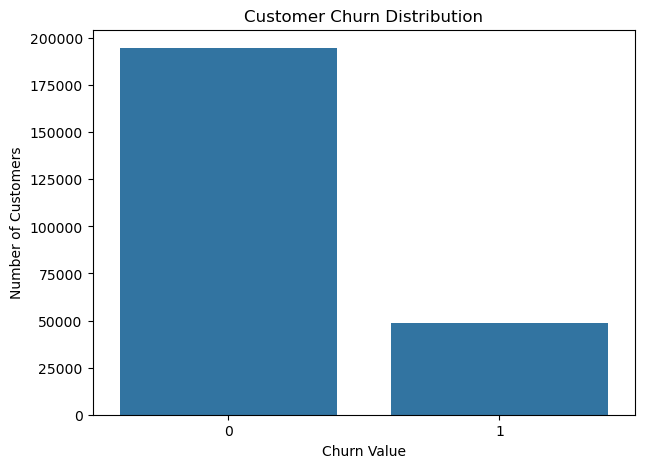

In [42]:
#1 Overall churn distribution
churn_counts = df["churn"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_counts.index.astype(str),
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Value")
plt.ylabel("Number of Customers")
plt.show()

In [43]:
#2 Calculate the overall churn rate
overall_churn_rate = df["churn"].mean() * 100

print("Overall churn rate:",
      round(overall_churn_rate, 2), "%")

Overall churn rate: 20.05 %


In [44]:
#3 Churn by telecom partner
partner_churn = (
    df.groupby("telecom_partner")["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean"
      )
      .reset_index()
)

partner_churn["churn_rate"] = (
    partner_churn["churn_rate"] * 100
).round(2)

partner_churn = partner_churn.sort_values(
    "churn_rate",
    ascending=False
)

partner_churn

,telecom_partner,total_customers,churn_rate
0,Airtel,60905,20.37
2,Reliance Jio,61123,20.02
3,Vodafone,60802,19.95
1,BSNL,60723,19.86


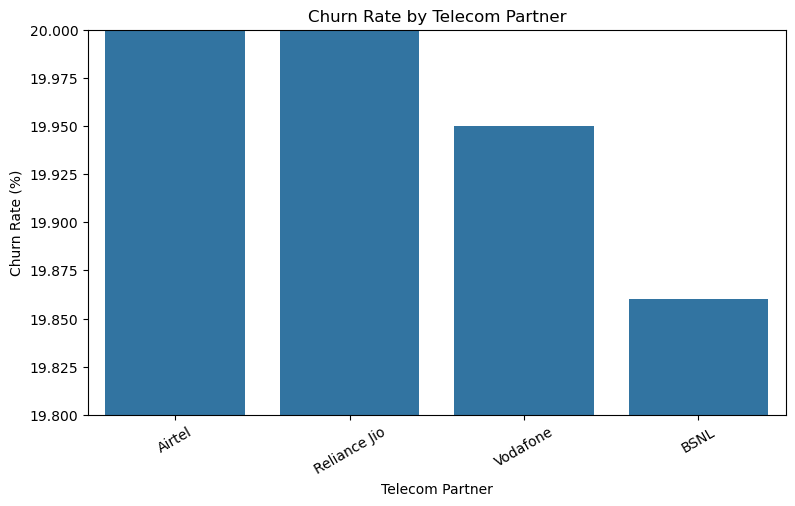

In [45]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=partner_churn,
    x="telecom_partner",
    y="churn_rate"
)
plt.ylim(19.8,20)

plt.title("Churn Rate by Telecom Partner")
plt.xlabel("Telecom Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [46]:
#4 Churn by gender
gender_churn = (
    df.groupby("gender")["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean"
      )
      .reset_index()
)

gender_churn["churn_rate"] = (
    gender_churn["churn_rate"] * 100
).round(2)

gender_churn

,gender,total_customers,churn_rate
0,F,97576,20.30
1,M,145977,19.88


In [47]:
#5 Churn by age group
age_group_churn = (
    df.groupby("age_group", observed=False)["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean"
      )
      .reset_index()
)

age_group_churn["churn_rate"] = (
    age_group_churn["churn_rate"] * 100
).round(2)

age_group_churn

,age_group,total_customers,churn_rate
0,18-25,34026,19.94
1,26-35,42302,20.06
2,36-45,42649,20.18
3,46-55,43005,19.96
4,56-65,42953,20.03
5,66+,38618,20.10


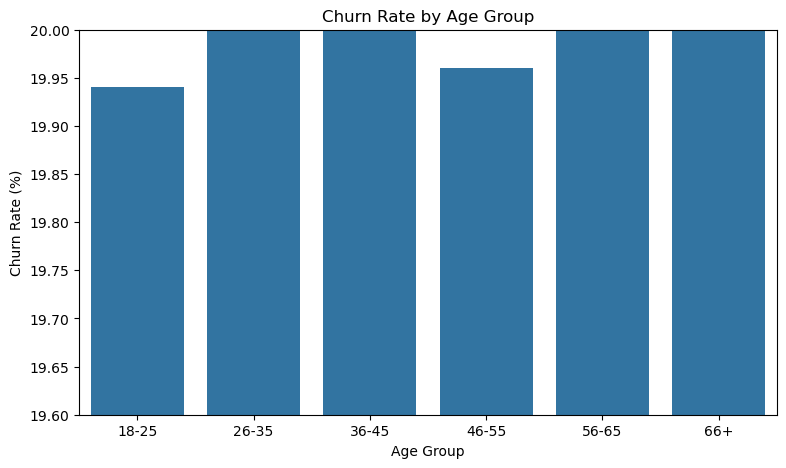

In [48]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_group_churn,
    x="age_group",
    y="churn_rate"
)
plt.ylim(19.6,20)
plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [49]:
#6 Churn by Indian state
state_churn = (
    df.groupby("state")["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean"
      )
      .reset_index()
)

state_churn["churn_rate"] = (
    state_churn["churn_rate"] * 100
).round(2)

state_churn = state_churn.sort_values(
    "churn_rate",
    ascending=False
)

state_churn.head(15)

,state,total_customers,churn_rate
9,Jharkhand,8755,21.12
10,Karnataka,8845,20.71
16,Mizoram,8689,20.65
26,Uttarakhand,8856,20.42
8,Himachal Pradesh,8682,20.41
12,Madhya Pradesh,8817,20.38
2,Assam,8547,20.30
18,Odisha,8712,20.25
17,Nagaland,8562,20.23
20,Rajasthan,8750,20.22


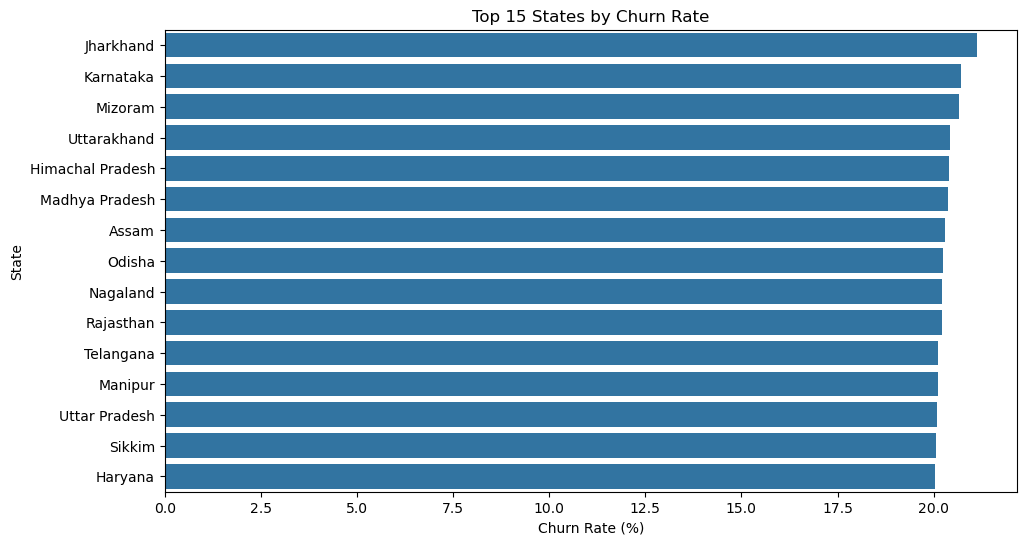

In [50]:
top_states = state_churn.head(15)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_states,
    x="churn_rate",
    y="state"
)
plt.title("Top 15 States by Churn Rate")
plt.xlabel("Churn Rate (%)")
plt.ylabel("State")
plt.show()

In [51]:
state_churn_count = (
    df.groupby("state")["churn"]
      .agg(
          total_customers="count",
          churned_customers="sum"
      )
      .reset_index()
)

state_churn_count = state_churn_count.sort_values(
    "churned_customers",
    ascending=False
)

state_churn_count.head(15)

,state,total_customers,churned_customers
9,Jharkhand,8755,1849
10,Karnataka,8845,1832
26,Uttarakhand,8856,1808
12,Madhya Pradesh,8817,1797
16,Mizoram,8689,1794
8,Himachal Pradesh,8682,1772
20,Rajasthan,8750,1769
18,Odisha,8712,1764
13,Maharashtra,8820,1756
25,Uttar Pradesh,8742,1755


In [52]:
#7 Churn by city
city_churn = (
    df.groupby("city")["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean",
          churned_customers="sum"
      )
      .reset_index()
)

city_churn["churn_rate"] = (
    city_churn["churn_rate"] * 100
).round(2)

city_churn = city_churn.sort_values(
    "churned_customers",
    ascending=False
)

city_churn.head(20)

,city,total_customers,churn_rate,churned_customers
3,Hyderabad,40698,20.42,8309
4,Kolkata,40661,20.16,8196
0,Bangalore,40603,20.05,8141
5,Mumbai,40386,20.16,8141
1,Chennai,40749,19.76,8050
2,Delhi,40456,19.75,7990


In [53]:
#8 Churn by salary group
salary_churn = (
    df.groupby("salary_group", observed=False)["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean"
      )
      .reset_index()
)

salary_churn["churn_rate"] = (
    salary_churn["churn_rate"] * 100
).round(2)

salary_churn

,salary_group,total_customers,churn_rate
0,0-25K,9295,19.80
1,25K-50K,46837,20.20
2,50K-100K,93730,20.19
3,100K-200K,93691,19.86
4,200K+,0,NaN


In [54]:
#9 Churn by data usage group
usage_churn = (
    df.groupby("data_usage_group", observed=False)["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean"
      )
      .reset_index()
)

usage_churn["churn_rate"] = (
    usage_churn["churn_rate"] * 100
).round(2)

usage_churn


,data_usage_group,total_customers,churn_rate
0,Low Usage,60904,19.79
1,Medium-Low Usage,63909,20.28
2,Medium-High Usage,57852,20.24
3,High Usage,60888,19.89


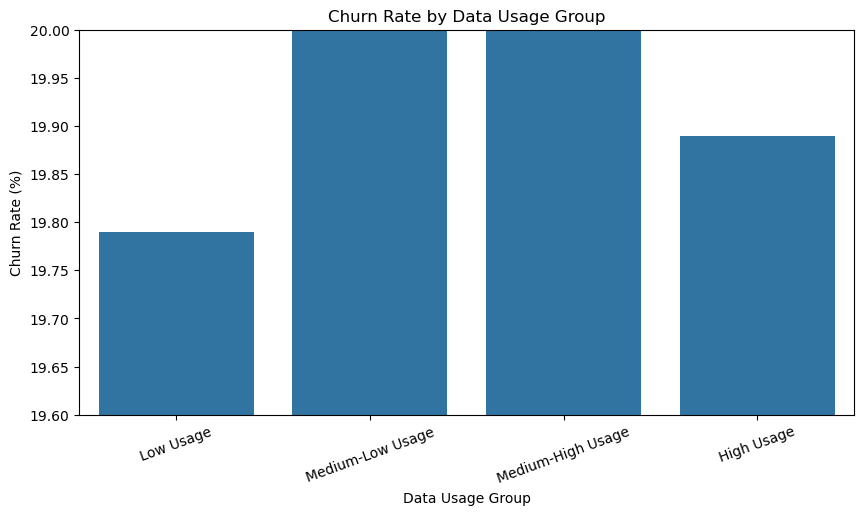

In [55]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=usage_churn,
    x="data_usage_group",
    y="churn_rate"
)
plt.ylim(19.6,20)
plt.title("Churn Rate by Data Usage Group")
plt.xlabel("Data Usage Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [56]:
#10 Churn by registration year
registration_churn = (
    df.groupby("registration_year")["churn"]
      .agg(
          total_customers="count",
          churn_rate="mean"
      )
      .reset_index()
)

registration_churn["churn_rate"] = (
    registration_churn["churn_rate"] * 100
).round(2)

registration_churn

,registration_year,total_customers,churn_rate
0,2020,73126,19.91
1,2021,72926,20.17
2,2022,72926,20.08
3,2023,24575,20.01


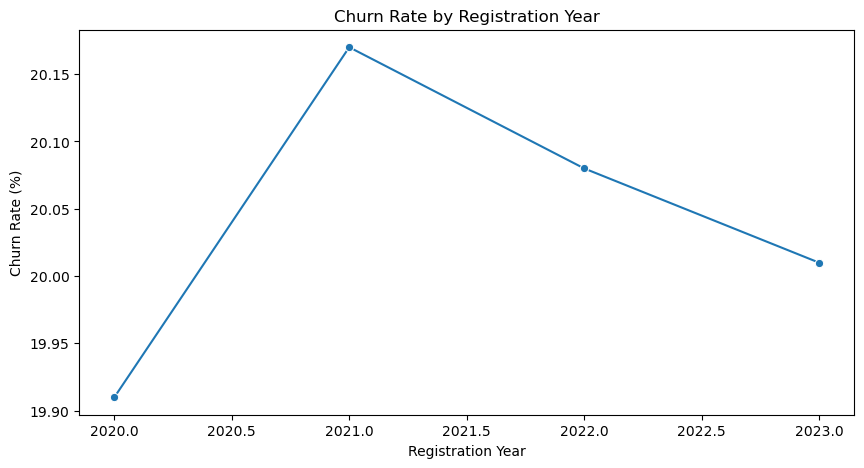

In [57]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=registration_churn,
    x="registration_year",
    y="churn_rate",
    marker="o"
)

plt.title("Churn Rate by Registration Year")
plt.xlabel("Registration Year")
plt.ylabel("Churn Rate (%)")
plt.show()

Create a Business-Ready Customer Segment

In [58]:
df[
    [
        "age",
        "estimated_salary",
        "calls_made",
        "sms_sent",
        "data_used",
        "num_dependents",
        "churn"
    ]
].describe()

,age,estimated_salary,calls_made,sms_sent,data_used,num_dependents,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,46.077609,85021.137839,50.498261,24.772776,5128.339893,1.997500,0.200478
std,16.444029,37508.963233,28.067381,13.981597,2816.489507,1.414941,0.400359
min,18.000000,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,52585.000000,27.000000,13.000000,2737.000000,1.000000,0.000000
50%,46.000000,84990.000000,50.000000,25.000000,5112.000000,2.000000,0.000000
75%,60.000000,117488.000000,74.000000,36.000000,7493.000000,3.000000,0.000000
max,74.000000,149999.000000,108.000000,53.000000,10991.000000,4.000000,1.000000


In [59]:
#Normalize
from sklearn.preprocessing import MinMaxScaler

usage_columns = [
    "calls_made",
    "sms_sent",
    "data_used"
]

scaler = MinMaxScaler()

df[
    [
        "calls_score",
        "sms_score",
        "data_score"
    ]
] = scaler.fit_transform(df[usage_columns])

In [60]:
#A. Engagement score
df["engagement_score"] = (
    df["calls_score"] +
    df["sms_score"] +
    df["data_score"]
) 

In [61]:
#B. Data usage category
df["data_usage_segment"] = pd.qcut(
    df["data_used"],
    q=3,
    labels=[
        "Low Data User",
        "Medium Data User",
        "High Data User"
    ],
    duplicates="drop"
)

In [62]:
#C. Salary category
df["salary_segment"] = pd.cut(
    df["estimated_salary"],
    bins=[
        0,
        25000,
        50000,
        100000,
        200000,
        float("inf")
    ],
    labels=[
        "Low Salary",
        "Lower-Middle Salary",
        "Middle Salary",
        "High Salary",
        "Very High Salary"
    ],
    include_lowest=True
)

In [63]:
#Main customer segment

#Engagement Categories
df["engagement_level"] = pd.cut(
    df["engagement_score"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=[
        "Low Engagement",
        "Medium Engagement",
        "High Engagement"
    ]
)

In [64]:
#Basic business segment
def create_customer_segment(row):
    if row["churn"] == 1 and row["engagement_level"] == "High Engagement":
        return "Highly Engaged but At Risk"

    elif row["churn"] == 1 and row["engagement_level"] == "Low Engagement":
        return "Low Engagement and At Risk"

    elif row["churn"] == 0 and row["engagement_level"] == "High Engagement":
        return "Loyal High-Engagement Customer"

    elif row["churn"] == 0 and row["engagement_level"] == "Low Engagement":
        return "Low Engagement Loyal Customer"

    else:
        return "Medium Engagement Customer"


df["customer_segment"] = df.apply(
    create_customer_segment,
    axis=1
)

In [65]:
#Number of customers in each segment
segment_counts = (
    df["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "customer_segment",
    "customer_count"
]

segment_counts

,customer_segment,customer_count
0,Medium Engagement Customer,205586
1,Loyal High-Engagement Customer,29396
2,Highly Engaged but At Risk,7311
3,Low Engagement Loyal Customer,1000
4,Low Engagement and At Risk,260


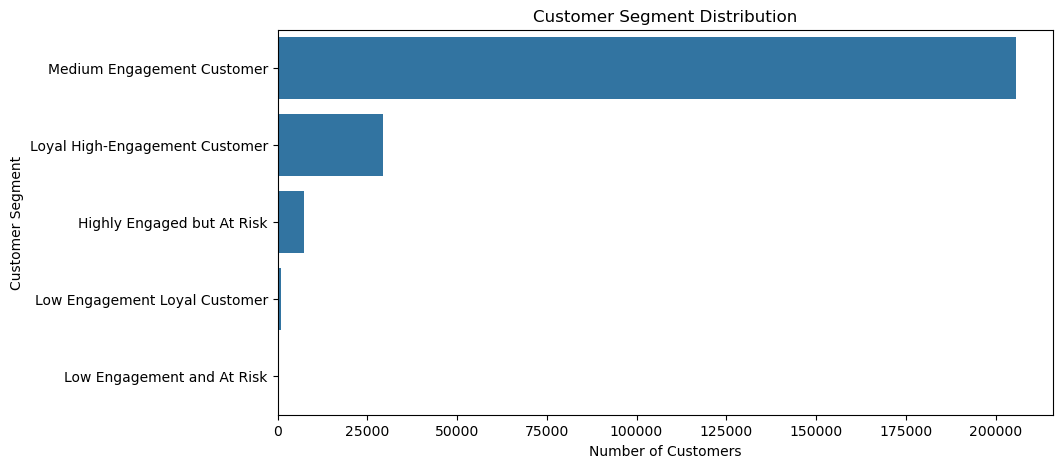

In [66]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="customer_segment",
    order=df["customer_segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.show()

In [67]:
#Calculate churn rate for each segment
segment_analysis = (
    df.groupby("customer_segment")
    .agg(
        total_customers=("customer_id", "count"),
        average_salary=("estimated_salary", "mean"),
        average_age=("age", "mean"),
        average_data_used=("data_used", "mean"),
        average_calls=("calls_made", "mean"),
        average_sms=("sms_sent", "mean"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

In [68]:
segment_analysis["churn_rate"] = (
    segment_analysis["churn_rate"] * 100
).round(2)

In [69]:
segment_analysis.sort_values(
    by="churn_rate",
    ascending=False
)

,customer_segment,total_customers,average_salary,average_age,average_data_used,average_calls,average_sms,churn_rate
0,Highly Engaged but At Risk,7311,85018.525510,46.041855,3233.209547,31.041992,14.905622,100.00
2,Low Engagement and At Risk,260,88187.903846,46.034615,1006.565385,8.942308,4.238462,100.00
4,Medium Engagement Customer,205586,84966.622742,46.051798,5497.193248,54.227034,26.658736,20.07
1,Low Engagement Loyal Customer,1000,83642.097000,46.365000,1022.443000,8.920000,4.201000,0.00
3,Loyal High-Engagement Customer,29396,85421.951592,46.257620,3196.164444,31.041332,14.918458,0.00


In [70]:
#business recommendations
def generate_recommendation(segment):
    if segment == "Highly Engaged but At Risk":
        return "Offer personalized retention plans and data benefits"

    elif segment == "Low Engagement and At Risk":
        return "Send reactivation offers and improve customer engagement"

    elif segment == "Loyal High-Engagement Customer":
        return "Provide loyalty rewards and premium plan benefits"

    elif segment == "Low Engagement Loyal Customer":
        return "Promote suitable low-cost plans and usage offers"

    else:
        return "Monitor customer activity and send relevant offers"


df["business_recommendation"] = (
    df["customer_segment"]
    .apply(generate_recommendation)
)

In [71]:
#final business summary
business_summary = (
    df.groupby(
        [
            "customer_segment",
            "business_recommendation"
        ]
    )
    .agg(
        total_customers=("customer_id", "count"),
        average_salary=("estimated_salary", "mean"),
        average_data_used=("data_used", "mean"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

business_summary["churn_rate"] = (
    business_summary["churn_rate"] * 100
).round(2)

business_summary

,customer_segment,business_recommendation,total_customers,average_salary,average_data_used,churn_rate
0,Highly Engaged but At Risk,Offer personalized retention plans and data be...,7311,85018.525510,3233.209547,100.00
1,Low Engagement Loyal Customer,Promote suitable low-cost plans and usage offers,1000,83642.097000,1022.443000,0.00
2,Low Engagement and At Risk,Send reactivation offers and improve customer ...,260,88187.903846,1006.565385,100.00
3,Loyal High-Engagement Customer,Provide loyalty rewards and premium plan benefits,29396,85421.951592,3196.164444,0.00
4,Medium Engagement Customer,Monitor customer activity and send relevant of...,205586,84966.622742,5497.193248,20.07


Churn Prediction Model

In [72]:
#Feature Engineering
features = [
    "age",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

X = df[features]
y = df["churn"]

In [73]:
#Train-test Split
from sklearn.model_selection import train_test_split
#(80% training data,20% testing data)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
#Train
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [75]:
y_pred = model.predict(X_test)

In [76]:
churn_probability = model.predict_proba(X_test)[:, 1]

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7995319332388988
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



In [78]:
import joblib

joblib.dump(
    model,
    "../models/logistic_churn_model.pkl"
)

['../models/logistic_churn_model.pkl']

In [79]:
#customer risk score
risk_df = X_test.copy()

risk_df["actual_churn"] = y_test
risk_df["churn_probability"] = churn_probability

In [80]:
#risk categories
def assign_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


risk_df["risk_level"] = (
    risk_df["churn_probability"]
    .apply(assign_risk)
)

Retention-Priority List

In [81]:
y_probability = model.predict_proba(X)[:, 1]

In [82]:
retention_df = df.copy()

retention_df["churn_probability"] = y_probability

In [83]:
#Risk Levels
retention_df["risk_level"] = pd.qcut(
    retention_df["churn_probability"],
    q=[0, 0.60, 0.85, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    duplicates="drop"
)

In [84]:
retention_df["risk_level"].value_counts()

risk_level
Low Risk       146132
Medium Risk     60888
High Risk       36533
Name: count, dtype: int64

In [85]:
retention_df["salary_score"] = (
    retention_df["estimated_salary"] /
    retention_df["estimated_salary"].max()
)

In [86]:
#Priority Score
retention_df["priority_score"] = (
    0.70 * retention_df["churn_probability"] +
    0.30 * retention_df["salary_score"]
)

In [87]:
#Prioritdef assign_priority(score):
retention_df["retention_priority"] = pd.qcut(
    retention_df["priority_score"],
    q=[0, 0.60, 0.85, 1.00],
    labels=[
        "Priority 3",
        "Priority 2",
        "Priority 1"
    ],
    duplicates="drop"
)

In [88]:
retention_df["retention_priority"].value_counts()

retention_priority
Priority 3    146132
Priority 2     60888
Priority 1     36533
Name: count, dtype: int64

In [89]:
#Recommendation action

data_usage_median = retention_df["data_used"].median()
def recommend_action(row):
    if row["risk_level"] == "High Risk":
        if row["data_used"] > data_usage_median:
            return "Offer a customized data plan"
        else:
            return "Send a personalized retention offer"

    elif row["risk_level"] == "Medium Risk":
        return "Send an engagement message or discount"

    else:
        return "Continue regular customer engagement"


retention_df["recommended_action"] = (
    retention_df.apply(recommend_action, axis=1)
)

In [90]:
#final priority list
retention_priority_list = retention_df[
    [
        "customer_id",
        "telecom_partner",
        "state",
        "city",
        "age",
        "estimated_salary",
        "calls_made",
        "sms_sent",
        "data_used",
        "churn_probability",
        "risk_level",
        "priority_score",
        "retention_priority",
        "recommended_action"
    ]
].sort_values(
    by="priority_score",
    ascending=False
)

In [91]:
retention_priority_list.head(50)

,customer_id,telecom_partner,state,city,age,estimated_salary,calls_made,sms_sent,data_used,churn_probability,risk_level,priority_score,retention_priority,recommended_action
189197,189198,BSNL,Uttarakhand,Hyderabad,68,149969,98.0,7.0,9797.0,0.202468,Medium Risk,0.441668,Priority 1,Send an engagement message or discount
63312,63313,Airtel,Telangana,Delhi,71,149742,90.0,15.0,10101.0,0.202978,Medium Risk,0.441570,Priority 1,Send an engagement message or discount
53024,53025,Airtel,Bihar,Mumbai,74,149858,52.0,7.0,9488.0,0.202615,Medium Risk,0.441549,Priority 1,Send an engagement message or discount
171347,171348,Reliance Jio,Bihar,Mumbai,56,149997,93.0,7.0,5150.0,0.202076,Medium Risk,0.441449,Priority 1,Send an engagement message or discount
11142,11143,Reliance Jio,Assam,Chennai,65,149977,90.0,23.0,6465.0,0.201764,Medium Risk,0.441191,Priority 1,Send an engagement message or discount
76856,76857,Vodafone,Uttarakhand,Hyderabad,63,149765,60.0,1.0,7932.0,0.202361,Medium Risk,0.441185,Priority 1,Send an engagement message or discount
122463,122464,Reliance Jio,Telangana,Hyderabad,46,149965,100.0,6.0,4688.0,0.201708,Medium Risk,0.441128,Priority 1,Send an engagement message or discount
234398,234399,BSNL,Mizoram,Kolkata,73,149937,82.0,34.0,9384.0,0.201755,Medium Risk,0.441104,Priority 1,Send an engagement message or discount
186589,186590,Vodafone,Meghalaya,Hyderabad,60,149752,82.0,5.0,6130.0,0.202273,Medium Risk,0.441097,Priority 1,Send an engagement message or discount
155816,155817,Airtel,Punjab,Mumbai,60,149839,92.0,11.0,4872.0,0.202017,Medium Risk,0.441092,Priority 1,Send an engagement message or discount


In [92]:
retention_priority_list.to_csv(
    "../data/processed/retention_priority_list.csv",
    index=False
)

Business dashboard

In [93]:
dashboard_df = retention_df.copy()

dashboard_df.to_csv(
    "../data/processed/telecom_dashboard_data.csv",
    index=False
)

POSTGRESQL CONNECTIVITY

In [95]:
!pip install psycopg2-binary sqlalchemy

In [100]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "Aditi0926" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "telecom_churn_db"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "telecom_customers"   # choose any table name
df = pd.read_csv(
    r'C:\Users\hp\OneDrive\Documents\CustomerPulse\data\processed\telecom_churn_cleaned.csv'
)
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'telecom_customers' in database 'telecom_churn_db'.
